In [3]:
"""
Water Usage Data Cleaning and Clustering with CAMEO Compression
Integrates data cleaning pipeline with autocorrelation-preserving compression
"""

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from tslearn.clustering import TimeSeriesKMeans
from statsmodels.tsa.stattools import acf
from scipy.interpolate import interp1d
import os
from google.colab import drive

In [4]:

# ============================================================================
# CONFIGURATION
# ============================================================================
TARGET_LENGTH = 10      # Compress to 10 points (adjustable: 8-15 recommended)
ACF_THRESHOLD = 0.3     # ACF significance threshold
OPTIMAL_K = 4           # Number of clusters

# ============================================================================
# CAMEO COMPRESSION FUNCTIONS
# ============================================================================

def calculate_acf_scores(series, max_lag=10):
    """Calculate ACF scores to identify important temporal dependencies."""
    if len(series) < 2 or np.std(series) < 1e-8:
        return np.zeros(min(max_lag, len(series) - 1))

    n_lags = min(max_lag, len(series) - 1)
    acf_values = acf(series, nlags=n_lags, fft=True)
    return acf_values[1:]


def identify_critical_points(series, acf_threshold=0.3, min_points=5, max_points=15):
    """Identify critical points based on ACF analysis and variation."""
    n = len(series)
    critical_indices = {0, n - 1}

    # Find significant lags
    acf_values = calculate_acf_scores(series, max_lag=min(15, n // 2))
    significant_lags = np.where(np.abs(acf_values) > acf_threshold)[0] + 1

    for lag in significant_lags[:5]:
        for i in range(lag, n, lag):
            critical_indices.add(i)
            if len(critical_indices) >= max_points:
                break
        if len(critical_indices) >= max_points:
            break

    # Add extrema points
    if len(critical_indices) < max_points and n > 2:
        diff1 = np.diff(series)
        if len(diff1) > 1:
            diff2 = np.diff(diff1)
            extrema = []
            for i in range(1, len(diff2)):
                if diff2[i-1] * diff2[i] < 0:
                    extrema.append(i + 1)

            extrema_values = [(idx, abs(series[idx] - np.mean(series))) for idx in extrema]
            extrema_values.sort(key=lambda x: x[1], reverse=True)

            for idx, _ in extrema_values:
                critical_indices.add(idx)
                if len(critical_indices) >= max_points:
                    break

    # Ensure minimum points
    if len(critical_indices) < min_points:
        step = max(1, n // min_points)
        for i in range(0, n, step):
            critical_indices.add(i)
            if len(critical_indices) >= min_points:
                break

    return np.array(sorted(critical_indices))


def cameo_compress(series, target_length=10, acf_threshold=0.3):
    """Apply CAMEO compression to a time series."""
    if len(series) <= target_length:
        return np.pad(series, (0, target_length - len(series)), mode='constant')

    critical_indices = identify_critical_points(
        series,
        acf_threshold=acf_threshold,
        min_points=target_length,
        max_points=min(len(series) // 2, target_length * 2)
    )

    critical_values = series[critical_indices]

    if len(critical_values) != target_length:
        f = interp1d(critical_indices, critical_values, kind='linear', fill_value='extrapolate')
        new_indices = np.linspace(0, len(series) - 1, target_length)
        compressed = f(new_indices)
    else:
        compressed = critical_values

    return compressed


def compress_dataset(time_series_data, target_length=10, acf_threshold=0.3):
    """Apply CAMEO compression to entire dataset."""
    n_meters = time_series_data.shape[0]
    compressed_data = np.zeros((n_meters, target_length))

    for i in range(n_meters):
        compressed_data[i] = cameo_compress(
            time_series_data[i],
            target_length=target_length,
            acf_threshold=acf_threshold
        )

    return compressed_data



In [6]:

# ============================================================================
# DATA LOADING AND CLEANING
# ============================================================================

print("="*70)
print("STEP 1: MOUNTING DRIVE AND LOADING DATA")
print("="*70)

drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Colab Notebooks/mapped_sample_2000rows.parquet"
df = pl.read_parquet(file_path)
print(f"✓ Loaded {df.height:,} rows")

# Load metadata
metermetadata = pl.read_parquet("/content/drive/MyDrive/Colab Notebooks/mapped_sample_2000rows.parquet")
print(f"✓ Loaded metadata: {metermetadata.height:,} rows")

# ============================================================================
# DATA CLEANING
# ============================================================================

print("\n" + "="*70)
print("STEP 2: CLEANING DATA")
print("="*70)

# Check for issues
negative_count = df.select((pl.col("water_usage_m3") < 0).sum().alias("negative_count"))
null_count = df.select(pl.col("water_usage_m3").is_null().sum().alias("null_count"))
print(f"Negative values: {negative_count.item()}")
print(f"Null values: {null_count.item()}")

# Clean the data - replace negatives, nulls, and NaNs with 0
cleaned_df = df.with_columns(
    pl.when(
        (pl.col("water_usage_m3") < 0) |
        (pl.col("water_usage_m3").is_null()) |
        (pl.col("water_usage_m3").is_nan())
    )
    .then(0)
    .otherwise(pl.col("water_usage_m3"))
    .alias("water_usage_m3")
)

print("✓ Data cleaned")
print(cleaned_df.head())

STEP 1: MOUNTING DRIVE AND LOADING DATA
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Loaded 2,000 rows
✓ Loaded metadata: 2,000 rows

STEP 2: CLEANING DATA
Negative values: 0
Null values: 0
✓ Data cleaned
shape: (5, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ meter_uui ┆ timestamp ┆ water_usa ┆ timestamp ┆ … ┆ timestamp ┆ timestamp ┆ meter_siz ┆ h3_index │
│ d         ┆ _UTC      ┆ ge_m3     ┆ _year     ┆   ┆ _day      ┆ _hour     ┆ e_inches  ┆ _res12   │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str       ┆ str       ┆ f64       ┆ i64       ┆   ┆ i64       ┆ i64       ┆ f64       ┆ str      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ dfba083f- ┆ 2024-08-1 ┆ 0.0       ┆ 2024      ┆ … ┆ 16        ┆ 14        ┆ 0.625     ┆

In [7]:

# ============================================================================
# MONTHLY FILE GENERATION WITH COMPRESSION
# ============================================================================

print("\n" + "="*70)
print("STEP 3: GENERATING CLEANED MONTHLY FILES")
print("="*70)

output_dir = "cleaned_monthly_files_with_compression/"
os.makedirs(output_dir, exist_ok=True)

# Find unique months
print("Scanning for unique months...")
unique_months = (
    pl.scan_parquet(file_path)
    .with_columns(
        pl.col("timestamp_UTC")
        .str.to_datetime()
        .dt.strftime("%Y-%m")
        .alias("year_month")
    )
    .select("year_month")
    .unique()
    .collect()
    .to_series()
)

print(f"Found months: {unique_months.to_list()}")

# Process each month
for month in unique_months:
    print(f"\nProcessing {month}...")
    filename = f"{output_dir}/cleaned_water_usage_{month}.parquet"

    # Extract and clean monthly data
    raw_monthly_data = (
        pl.scan_parquet(file_path)
        .with_columns(
            pl.col("timestamp_UTC")
            .str.to_datetime()
            .dt.strftime("%Y-%m")
            .alias("year_month")
        )
        .filter(pl.col("year_month") == month)
        .collect()
    )

    cleaned_monthly_data = raw_monthly_data.with_columns(
        pl.when(
            (pl.col("water_usage_m3") < 0) |
            (pl.col("water_usage_m3").is_null()) |
            (pl.col("water_usage_m3").is_nan())
        )
        .then(0)
        .otherwise(pl.col("water_usage_m3"))
        .alias("water_usage_m3")
    )

    # Save cleaned monthly file
    cleaned_monthly_data.write_parquet(filename)
    print(f"  ✓ Saved: {filename}")

print("\n✓ All monthly files generated")



STEP 3: GENERATING CLEANED MONTHLY FILES
Scanning for unique months...
Found months: ['2024-07', '2024-08']

Processing 2024-07...
  ✓ Saved: cleaned_monthly_files_with_compression//cleaned_water_usage_2024-07.parquet

Processing 2024-08...
  ✓ Saved: cleaned_monthly_files_with_compression//cleaned_water_usage_2024-08.parquet

✓ All monthly files generated



STEP 4: CLUSTERING WITH CAMEO COMPRESSION

Analyzing 2024-08...
Original shape: (1, 16)

Applying CAMEO compression to 10 dimensions...
Compressed shape: (1, 10)
Compression ratio: 1.60x


/tmp/ipython-input-643403365.py:37: DeprecationWarning: The argument `columns` for `DataFrame.pivot` is deprecated. It has been renamed to `on`.
  df_wide = df_daily.pivot(


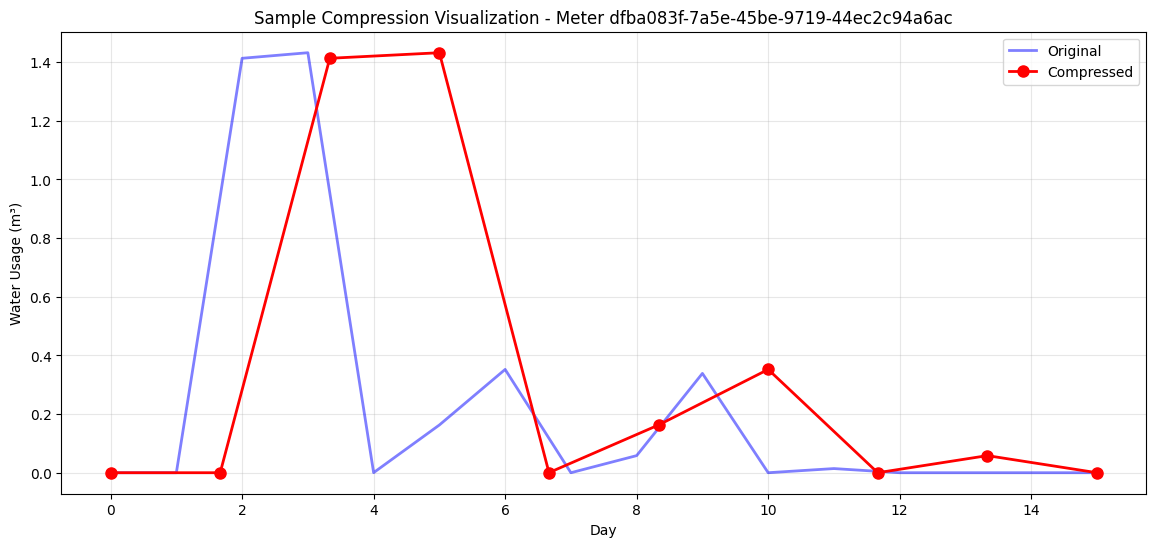


Clustering with k=4...

Cluster distribution:
shape: (1, 2)
┌─────────┬───────┐
│ cluster ┆ count │
│ ---     ┆ ---   │
│ i64     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 1     │
└─────────┴───────┘

✓ Saved cluster assignments: cleaned_monthly_files_with_compression//meter_clusters_2024-08_compressed.csv


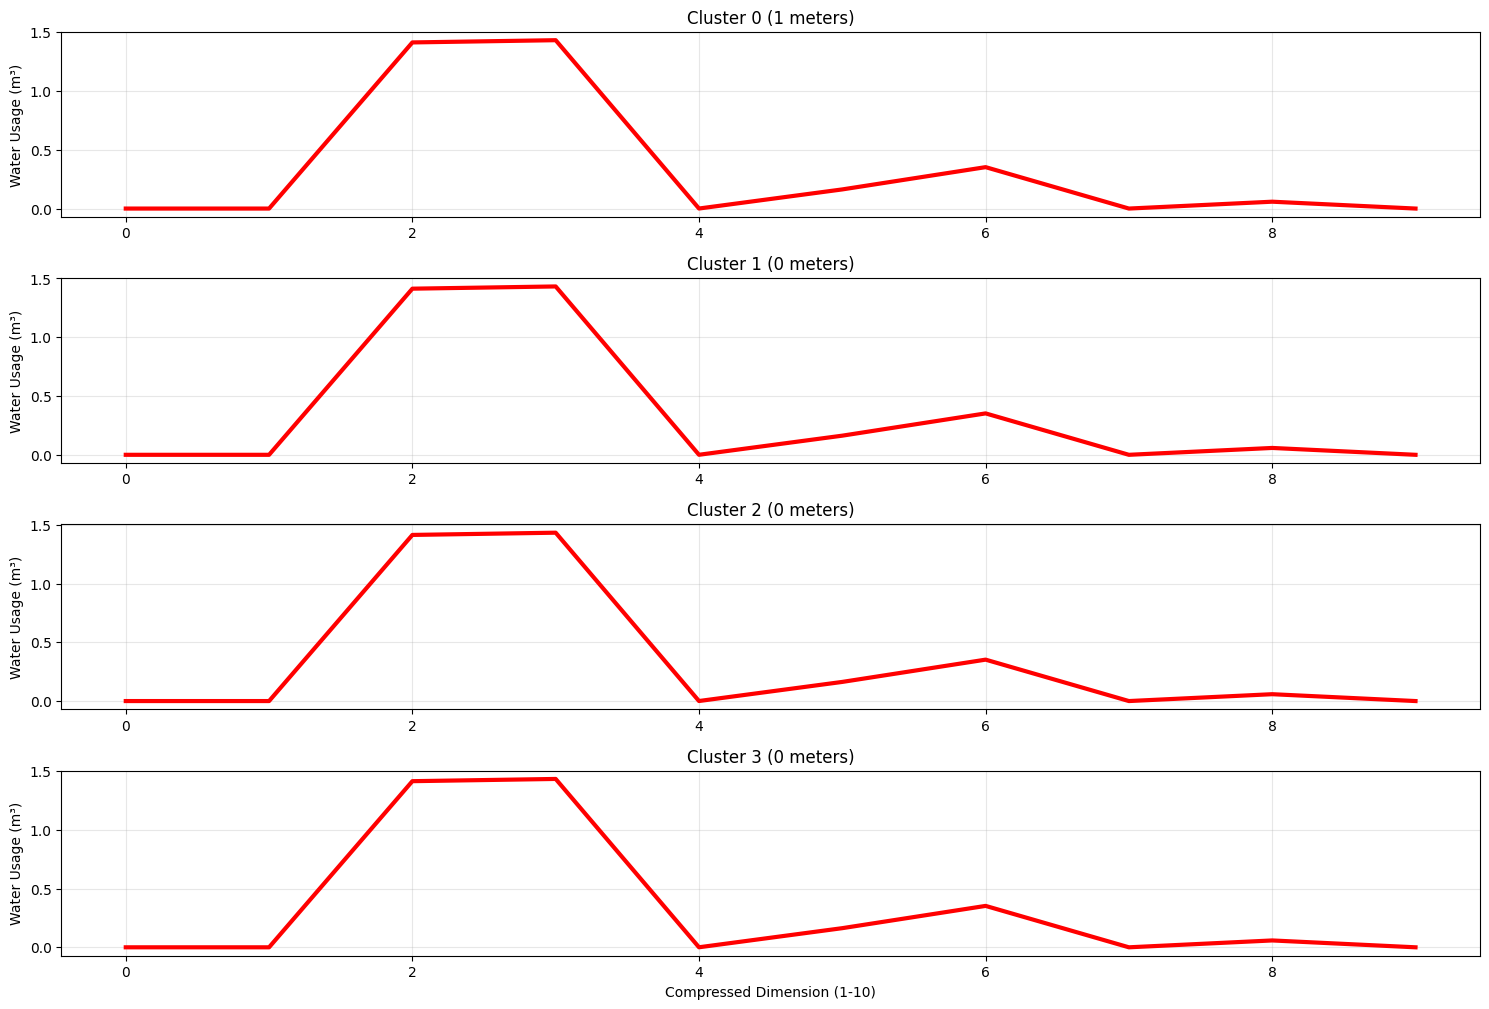


✓ Clustering complete!

PIPELINE COMPLETE


In [9]:

# ============================================================================
# CLUSTERING WITH COMPRESSION (Example for one month)
# ============================================================================

print("\n" + "="*70)
print("STEP 4: CLUSTERING WITH CAMEO COMPRESSION")
print("="*70)

# Select a month to cluster
source_month = "2024-08"  # Change as needed
source_file = f"{output_dir}/cleaned_water_usage_{source_month}.parquet"

if os.path.exists(source_file):
    print(f"\nAnalyzing {source_month}...")

    df_month = pl.read_parquet(source_file)

    # Convert timestamp to datetime if it's a string
    df_month = df_month.with_columns(
        pl.col("timestamp_UTC").str.to_datetime()
    )

    df_sorted = df_month.sort("meter_uuid", "timestamp_UTC")

    # Aggregate to daily sums
    df_daily = df_sorted.group_by_dynamic(
        "timestamp_UTC",
        every="1d",
        group_by="meter_uuid"  # Updated parameter name
    ).agg(
        pl.sum("water_usage_m3")
    ).with_columns(
        day=pl.col("timestamp_UTC").dt.day()
    )

    # Pivot to wide format
    df_wide = df_daily.pivot(
        index="meter_uuid",
        columns="day",
        values="water_usage_m3"
    )

    df_filled = df_wide.fill_null(0)
    meter_ids = df_filled["meter_uuid"]
    time_series_data = df_filled.drop("meter_uuid").to_numpy()

    print(f"Original shape: {time_series_data.shape}")

    # Apply CAMEO compression
    print(f"\nApplying CAMEO compression to {TARGET_LENGTH} dimensions...")
    compressed_data = compress_dataset(
        time_series_data,
        target_length=TARGET_LENGTH,
        acf_threshold=ACF_THRESHOLD
    )

    print(f"Compressed shape: {compressed_data.shape}")
    print(f"Compression ratio: {time_series_data.shape[1] / TARGET_LENGTH:.2f}x")

    # Visualize compression
    plt.figure(figsize=(14, 6))
    sample_idx = 0
    plt.plot(range(len(time_series_data[sample_idx])), time_series_data[sample_idx],
             'b-', alpha=0.5, label='Original', linewidth=2)
    plt.plot(np.linspace(0, len(time_series_data[sample_idx])-1, len(compressed_data[sample_idx])),
             compressed_data[sample_idx], 'ro-', label='Compressed', markersize=8, linewidth=2)
    plt.title(f'Sample Compression Visualization - Meter {meter_ids[sample_idx]}')
    plt.xlabel('Day')
    plt.ylabel('Water Usage (m³)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{output_dir}/compression_sample_{source_month}.png', dpi=150)
    plt.show()

    # Run clustering on compressed data
    print(f"\nClustering with k={OPTIMAL_K}...")
    final_km = TimeSeriesKMeans(
        n_clusters=OPTIMAL_K,
        metric="dtw",
        max_iter=10,
        random_state=42,
        n_jobs=-1
    )
    cluster_labels = final_km.fit_predict(compressed_data)

    # Save results
    results = pl.DataFrame({
        "meter_uuid": meter_ids,
        "cluster": cluster_labels
    })

    print("\nCluster distribution:")
    print(results["cluster"].value_counts(sort=True))

    output_csv = f"{output_dir}/meter_clusters_{source_month}_compressed.csv"
    results.write_csv(output_csv)
    print(f"\n✓ Saved cluster assignments: {output_csv}")

    # Visualize clusters
    plt.figure(figsize=(15, 10))
    for i in range(OPTIMAL_K):
        plt.subplot(OPTIMAL_K, 1, i + 1)
        cluster_series = compressed_data[cluster_labels == i]
        for series in cluster_series:
            plt.plot(series.ravel(), "k-", alpha=.2)
        plt.plot(final_km.cluster_centers_[i].ravel(), "r-", linewidth=3)
        plt.title(f"Cluster {i} ({len(cluster_series)} meters)")
        plt.ylabel("Water Usage (m³)")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.xlabel(f"Compressed Dimension (1-{TARGET_LENGTH})")
    plt.savefig(f'{output_dir}/clusters_{source_month}.png', dpi=150)
    plt.show()

    print("\n✓ Clustering complete!")
else:
    print(f"File not found: {source_file}")

print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)